In [14]:
# importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [15]:
# Load data
df = pd.read_csv('wildfire_data_with_clusters.csv')
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Data loaded: 9,509,925 rows × 21 columns


,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,...,vs,bi,fm100,fm1000,erc,etr,pet,vpd,Wildfire_binary,cluster_id
0,48.128431,-97.276685,2018-08-15,No,-0.053101,-0.050631,-0.063031,-0.052081,-0.021598,-0.051093,...,-0.052530,-0.048324,-0.053601,-0.053433,-0.045941,-0.050984,-0.051275,-0.051811,0,3
1,48.128431,-97.276685,2018-08-16,No,-0.053101,-0.049571,-0.063620,-0.052080,-0.026678,-0.049967,...,-0.052530,-0.048324,-0.053895,-0.053551,-0.044765,-0.050573,-0.051040,-0.051612,0,3
2,48.128431,-97.276685,2018-08-17,No,-0.053101,-0.055165,-0.059797,-0.052080,-0.025733,-0.048841,...,-0.052471,-0.048324,-0.054189,-0.053609,-0.044765,-0.051161,-0.051393,-0.051858,0,3
3,48.128431,-97.276685,2018-08-18,No,-0.050163,-0.058522,-0.060385,-0.052080,-0.028214,-0.046945,...,-0.051296,-0.071849,-0.053777,-0.053551,-0.054178,-0.049515,-0.050453,-0.051659,0,3
4,48.128431,-97.276685,2018-08-19,No,-0.053101,-0.038028,-0.046975,-0.052079,-0.084101,-0.050027,...,-0.051531,-0.047736,-0.052661,-0.053492,-0.050059,-0.052688,-0.052509,-0.052358,0,3


In [17]:
# separate columns into features and target
# columns related to weather conditions
weather_cols = [
    'pr','rmax','rmin','sph','srad','tmmn','tmmx','vs',
    'bi','fm100','fm1000','erc','etr','pet','vpd'
]

# columns related to geographical context
geo_cols = ['latitude', 'longitude']
cluster_col = ['cluster_id']

feature_cols = geo_cols + weather_cols + cluster_col

X = df[feature_cols]
y = df['Wildfire_binary'] # target variable indicating wildfire occurrence

In [18]:
# Stratified Shuffle Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain rows: {len(X_train):,}")
print(f" Test rows: {len(X_test):,}")


Train rows: 7,607,940
 Test rows: 1,901,985


In [19]:
# Train fire counts
print(f"Training set fire counts:\n{y_train.value_counts()}")
# Test fire counts
print(f"\nTesting set fire counts:\n{y_test.value_counts()}")

# Train cluster distribution
print(f"\nTraining set cluster distribution:\n{X_train['cluster_id'].value_counts()}")
# Test cluster distribution
print(f"\nTesting set cluster distribution:\n{X_test['cluster_id'].value_counts()}")

Training set fire counts:
Wildfire_binary
0    7206288
1     401652
Name: count, dtype: int64

Testing set fire counts:
Wildfire_binary
0    1801572
1     100413
Name: count, dtype: int64

Training set cluster distribution:
cluster_id
2    2327300
0    2082659
1    1616623
3    1161263
5     399531
4      20564
Name: count, dtype: int64

Testing set cluster distribution:
cluster_id
2    582100
0    521416
1    403502
3    290137
5     99669
4      5161
Name: count, dtype: int64


In [24]:
# Amplify the fire weight by 1.1 to further prioritize the rare class
fire_weight = ((y_train == 0).sum() / max(y_train.sum(), 1)) * 1.1
sample_weight = np.where(y_train==1, fire_weight, 1)
print(f"Fire weight (Amplified): {fire_weight:.2f}")

# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1, verbose=1)
rf_model.fit(X_train, y_train, sample_weight=sample_weight)
print("Training complete.")

Fire weight (Amplified): 19.74


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.7min


Training complete.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  7.3min finished


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    2.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.8s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    2.2s finished


Accuracy: 0.5161
ROC-AUC Score: 0.6838

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.50      0.66   1801572
           1       0.08      0.75      0.14    100413

    accuracy                           0.52   1901985
   macro avg       0.53      0.63      0.40   1901985
weighted avg       0.93      0.52      0.64   1901985



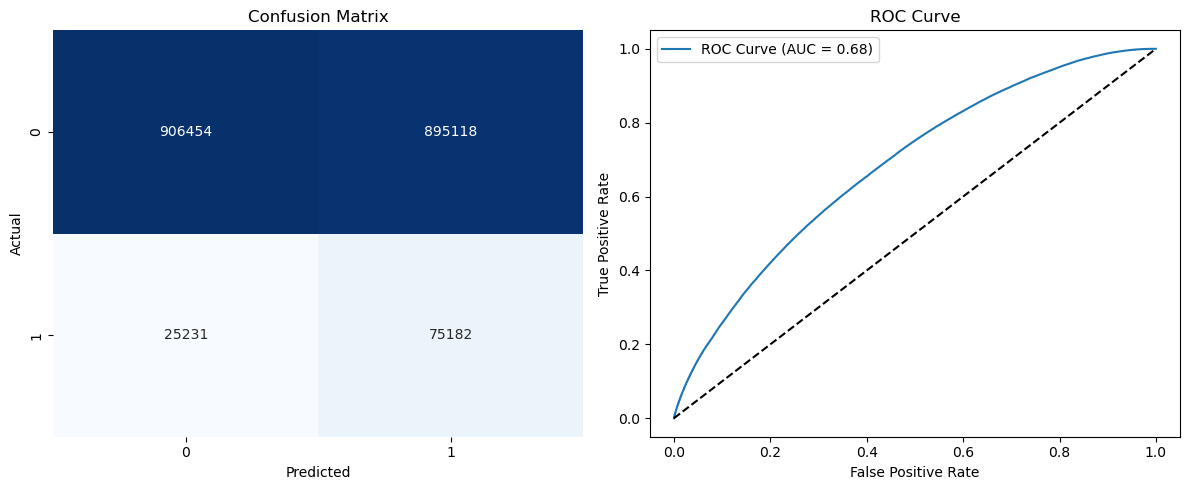

In [25]:
# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

Feature Ranking:
1. longitude (0.2034)
2. fm1000 (0.1975)
3. latitude (0.1729)
4. erc (0.0705)
5. cluster_id (0.0672)
6. srad (0.0622)
7. sph (0.0366)
8. tmmx (0.0357)
9. tmmn (0.0344)
10. fm100 (0.0259)
11. pet (0.0209)
12. bi (0.0188)
13. vpd (0.0130)
14. etr (0.0116)
15. rmin (0.0104)
16. vs (0.0074)
17. rmax (0.0062)
18. pr (0.0054)


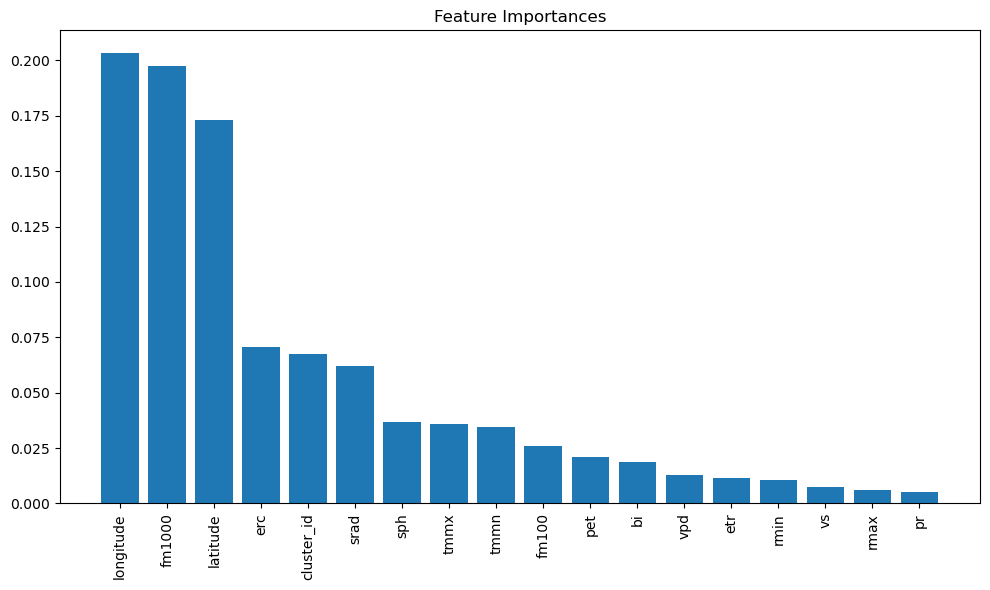

In [23]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Ranking:")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. {feature_cols[indices[f]]} ({importances[indices[f]]:.4f})")

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()